# Exercise 04 — Recurrent Neural Networks

Last week you averaged word vectors into a single sentence vector — and saw that this throws away **word order** entirely. This week you use models that read a text **one token at a time** and carry a hidden state along the way: the vanilla **RNN**, the **LSTM** and the **GRU**. You train all three to classify news articles and compare them.

## What you will do
1. **Explore the data** — the AG News dataset: how big it is, how long the articles are, how the labels are distributed.
2. **From text to tensors** — tokenize the articles with a pre-trained tokenizer and wrap them in `DataLoader`s.
3. **Build an RNN classifier** — embedding → recurrent layer → linear layer.
4. **Train and evaluate it** — complete the training loop and measure per-class and macro F1.
5. **LSTM and GRU** — swap the recurrent layer, retrain, and compare the three models.
6. **Multiple-choice questions** — to check your understanding.

## How to work through it
- Run the cells **in order** and fill in **every `# TODO`**.
- Tasks are numbered (**1.1**, **1.2**, …). Tasks that say *Your answer here* want a short written answer, not code.
- Most implementation tasks are followed by a **✅ Check** cell that verifies your work automatically. Run it and make sure it passes before you move on.

> **Heads up — this notebook downloads data and trains three models.** The AG News dataset (~30 MB) and the tokenizer are downloaded in the first cells. Each model trains for 3 epochs on 120k articles, which takes roughly 3–6 minutes per model on a CPU. Start each training cell as soon as it is ready and read ahead while it runs.

Please update your environment before running this notebook using <code onclick="navigator.clipboard.writeText(this.textContent)" style="cursor:pointer" title="Click to copy">uv sync</code> — this week adds the `transformers` library.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from datasets import load_dataset
from transformers import AutoTokenizer
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

torch.manual_seed(0)

# Use the GPU if there is one; a CPU is enough for this notebook.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cpu device


## 1. The data: AG News

We use the **AG News** topic-classification dataset. It was built from a corpus of more than one million news articles by keeping the four largest categories: **World**, **Sports**, **Business** and **Sci/Tech**. Every article is a short title plus description, labelled with one of the four topics.

Each example looks like this:

```
{"label": 3,
 "text": "New iPad released Just like every other September, this one is no different. Apple is planning to release a bigger, heavier, fatter iPad that..."}
```

The dataset comes from the Hugging Face Hub, via the `datasets` library you already used last week. The first call downloads it (~30 MB); after that it is cached on disk.

*Xiang Zhang, Junbo Zhao, Yann LeCun. 2015. Character-level Convolutional Networks for Text Classification. NeurIPS 2015.*

In [2]:
dataset = load_dataset("fancyzhx/ag_news")

train_data = dataset["train"]
test_data = dataset["test"]

# The human-readable name of each label id
LABEL_NAMES = train_data.features["label"].names

print(dataset)
print("Labels:", LABEL_NAMES)

print("\nA few training examples:")
for row in train_data.select(range(3)):
    print(f"  [{LABEL_NAMES[row['label']]:<8}] {row['text'][:100]}...")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Labels: ['World', 'Sports', 'Business', 'Sci/Tech']

A few training examples:
  [Business] Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...
  [Business] Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,...
  [Business] Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about th...


### Exploring the data

Before building anything, look at the data.

**1.1 Fill in the four blanks below.**

Hints:
- `len(train_data)` gives the number of rows; `train_data["text"]` gives the whole column as a plain Python list.
- Count the words of an article with `len(text.split())` — a rough count, but good enough to get a feel for the length.
- `Counter(train_data["label"])` counts how often each label id occurs.

In [3]:
n_train = len(train_data)
n_test = len(test_data)
avg_words = np.mean([len(text.split()) for text in train_data["text"]])
label_counts = Counter(train_data["label"])

print(f"Training articles : {n_train:,}")
print(f"Test articles     : {n_test:,}")
print(f"Average length    : {avg_words:.1f} words")
print("Label distribution:")
for label, count in sorted(label_counts.items()):
    print(f"   {label} = {LABEL_NAMES[label]:<9} {count:,}")

Training articles : 120,000
Test articles     : 7,600
Average length    : 37.8 words
Label distribution:
   0 = World     30,000
   1 = Sports    30,000
   2 = Business  30,000
   3 = Sci/Tech  30,000


In [4]:
# ✅ Check your numbers
assert n_train == 120_000, f"expected 120,000 training articles, got {n_train}"
assert n_test == 7_600, f"expected 7,600 test articles, got {n_test}"
assert 30 < avg_words < 50, f"an article has a few dozen words on average, you got {avg_words}"
assert sorted(label_counts) == [0, 1, 2, 3], "there should be exactly four label ids, 0-3"
assert all(count == 30_000 for count in label_counts.values()), "every class has exactly 30,000 training articles"
print("Looks good ✅")

Looks good ✅


**1.2 The dataset is perfectly balanced. Imagine it were not — say 90% of all articles were *Sports*.** Why would plain accuracy be a misleading way to evaluate a classifier on such data, and what does **macro-F1** (the metric we use below) do differently?

---

*Answer:*

With 90% *Sports*, a "classifier" that ignores its input and always says *Sports* is **90% accurate** — while being useless on the three classes we would actually need it for. Accuracy counts articles, so the majority class dominates it and failures on the rare classes are hidden.

**Macro-F1** computes an F1 score for every class separately and then takes their **unweighted** mean, so every class counts equally no matter how many articles it has. The always-*Sports* classifier gets an F1 of about 0.95 on *Sports* but **0** on the other three classes (no true positives), i.e. a macro-F1 of only about 0.24. F1 also combines precision and recall, so a class cannot be "won" by predicting it all the time (low precision) or almost never (low recall).

On AG News the classes are perfectly balanced, so accuracy and macro-F1 end up very close — but the per-class F1 scores still tell us *which* topics the model confuses.

---

## 2. From text to tensors

A neural network cannot read strings. We need to **tokenize** every article — split it into tokens and map each token to an integer id — so that we can look those ids up in an embedding matrix.

Instead of building a vocabulary ourselves, we borrow the **pre-trained tokenizer of BERT** (`bert-base-uncased`) from the `transformers` library. It is a *subword* tokenizer: common words stay whole, rare words are split into pieces (`##ing`, `##ly`, …), so it never meets a word it cannot handle. A few things to know:

- Its vocabulary has **30,522** entries — this will be the size of our embedding matrix.
- Everything is **lowercased**.
- It adds two special tokens: `[CLS]` at the start and `[SEP]` at the end.
- The padding token `[PAD]` has id **0**.

We only use the tokenizer this week. Next week you will meet the model it belongs to.

In [5]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

example = train_data[0]["text"]
encoded = tokenizer(example)

print("Text   :", example)
print("Tokens :", tokenizer.convert_ids_to_tokens(encoded["input_ids"]))
print("IDs    :", encoded["input_ids"])

print(f"\nVocabulary size: {tokenizer.vocab_size:,}")
print(f"Padding token  : {tokenizer.pad_token!r} with id {tokenizer.pad_token_id}")

Text   : Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Tokens : ['[CLS]', 'wall', 'st', '.', 'bears', 'claw', 'back', 'into', 'the', 'black', '(', 'reuters', ')', 'reuters', '-', 'short', '-', 'sellers', ',', 'wall', 'street', "'", 's', 'd', '##wind', '##ling', '\\', 'band', 'of', 'ultra', '-', 'cy', '##nic', '##s', ',', 'are', 'seeing', 'green', 'again', '.', '[SEP]']
IDs    : [101, 2813, 2358, 1012, 6468, 15020, 2067, 2046, 1996, 2304, 1006, 26665, 1007, 26665, 1011, 2460, 1011, 19041, 1010, 2813, 2395, 1005, 1055, 1040, 11101, 2989, 1032, 2316, 1997, 11087, 1011, 22330, 8713, 2015, 1010, 2024, 3773, 2665, 2153, 1012, 102]

Vocabulary size: 30,522
Padding token  : '[PAD]' with id 0


### Fixed-length sequences

The example above has whatever length it happens to have, but to process articles in **mini-batches** we need every sequence in a batch to have the **same length**. The standard fix:

- articles that are **too long** are **truncated**,
- articles that are **too short** are **padded** with `[PAD]` tokens.

We use a fixed length of `MAX_LEN = 50` tokens.

One detail matters for recurrent models: **on which side to pad**. By default the tokenizer pads on the *right*, so a short article ends in a run of `[PAD]` tokens — and our classifier will read the hidden state after the *last* position (Part 3). We therefore tell the tokenizer to pad on the **left**, so that the last position is always a real token. You will think about *why* this matters in 3.3.

**2.1 Complete `encode` so that every article is turned into exactly `MAX_LEN` token ids.**

Hints:
- The tokenizer does all of it for you if you pass the right arguments: `padding="max_length"`, `truncation=True` and `max_length=MAX_LEN`.
- `dataset.map(encode, batched=True)` hands `encode` a **batch** of rows as a dict of lists, so `batch["text"]` is a list of strings — the tokenizer accepts a list directly.
- `map` adds the tokenizer's output (`input_ids`, `attention_mask`, …) as new columns.

In [6]:
MAX_LEN = 50
tokenizer.padding_side = "left"  # pad at the start, so the last position is always a real token

def encode(batch):
    # Pad short articles and truncate long ones, so every sequence has exactly MAX_LEN token ids
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=MAX_LEN)


encoded_dataset = dataset.map(encode, batched=True)
print(encoded_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})


In [7]:
# ✅ Check your encoding
assert "input_ids" in encoded_dataset["train"].column_names, "map should have added an 'input_ids' column"

sample_ids = encoded_dataset["train"][:200]["input_ids"]
assert all(len(ids) == MAX_LEN for ids in sample_ids), "every sequence must have exactly MAX_LEN ids — did you set padding and truncation?"

shortest = max(sample_ids, key=lambda ids: ids.count(tokenizer.pad_token_id))
print("A short article, padded:")
print(tokenizer.convert_ids_to_tokens(shortest))
assert shortest[0] == tokenizer.pad_token_id, "short articles should *start* with [PAD] tokens — is padding_side set to 'left'?"
assert shortest[-1] != tokenizer.pad_token_id, "the last position should be a real token ([SEP])"
print("Looks good ✅")

A short article, padded:
['[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[CLS]', 'quality', 'gets', 'swept', 'away', 'quality', 'distribution', 'is', 'hammered', 'after', 'reporting', 'a', 'large', 'loss', 'for', 'the', 'second', 'quarter', '.', '[SEP]']
Looks good ✅


**2.2 How much do we lose by truncating?** Tokenize a sample of training articles *without* padding or truncation and compute the fraction that is longer than `MAX_LEN` tokens.

Hints:
- Calling `tokenizer(list_of_texts)` with no other arguments returns the *natural* length of each article.
- `tokenizer(...)["input_ids"]` is a list of lists — one list of ids per article. Take `len` of each.
- 5,000 articles are plenty to get a reliable estimate, and it takes well under a second.

Average length  : 56.0 tokens
Longest article : 342 tokens
Truncated       : 58.4% of the articles are longer than 50 tokens


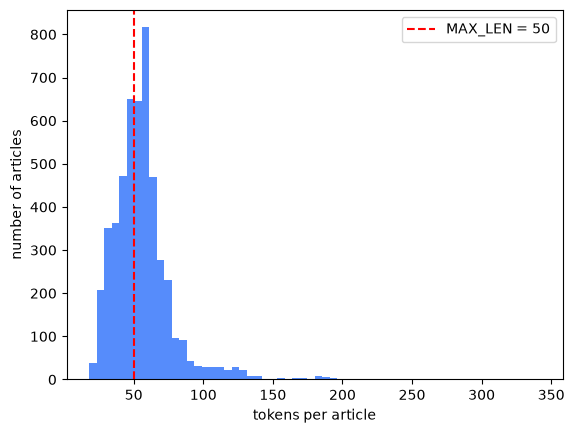

In [8]:
sample_texts = train_data["text"][:5000]

token_lengths = [len(ids) for ids in tokenizer(sample_texts)["input_ids"]]
fraction_truncated = np.mean(np.array(token_lengths) > MAX_LEN)

print(f"Average length  : {np.mean(token_lengths):.1f} tokens")
print(f"Longest article : {np.max(token_lengths)} tokens")
print(f"Truncated       : {100 * fraction_truncated:.1f}% of the articles are longer than {MAX_LEN} tokens")

plt.hist(token_lengths, bins=60)
plt.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
plt.xlabel("tokens per article")
plt.ylabel("number of articles")
plt.legend()
plt.show()

**2.3 Is 50 a reasonable choice?** Roughly half of the articles get cut. Why might that still be fine for *topic* classification, and what is the price of raising `MAX_LEN` to, say, 200?

---

*Answer:*

The **topic** of a news article is usually obvious from its beginning: the text is the *title followed by the description*, and news writing puts the most important information first. The first 50 tokens almost always contain the give-away words (team names, companies, countries, products), so cutting the tail costs very little for this task. It would be a much worse idea for a task where the decisive information can come late, e.g. a review that ends with "…but in the end I hated it".

Raising `MAX_LEN` to 200 has a price:
- **Compute** — an RNN processes the sequence step by step, so time and memory grow linearly with the length: roughly 4× slower training, and the steps cannot be parallelised.
- **Mostly padding** — almost no article is that long, so most of the 200 positions would be `[PAD]` tokens that the model still has to step through.
- **Harder optimisation** — backpropagating through 200 steps instead of 50 makes vanishing/exploding gradients worse, which hurts the vanilla RNN most: with left padding the informative beginning of the article is then up to 200 steps away from the final hidden state.

---

### DataLoaders

The encoded dataset holds Python lists. Convert them into tensors and wrap them in the same `TensorDataset` / `DataLoader` combination you used in the previous weeks.

**2.4 Complete `to_torch_dataset` and create the two `DataLoader`s.**

Hints:
- `split["input_ids"]` and `split["label"]` are lists — `torch.tensor(..., dtype=torch.long)` turns them into tensors of shape `(n, MAX_LEN)` and `(n,)`. Token ids and class labels both need to be `long` (integer) tensors.
- Shuffle the **training** loader so that every epoch sees the articles in a different order; the test loader does not need shuffling.

In [9]:
BATCH_SIZE = 64

def to_torch_dataset(split):
    inputs = torch.tensor(split["input_ids"], dtype=torch.long)  # (n, MAX_LEN)
    labels = torch.tensor(split["label"], dtype=torch.long)      # (n,)
    return TensorDataset(inputs, labels)


train_dataset = to_torch_dataset(encoded_dataset["train"])
test_dataset = to_torch_dataset(encoded_dataset["test"])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [10]:
# ✅ Check your DataLoaders
X, y = next(iter(train_loader))
print(f"One batch: X {tuple(X.shape)} {X.dtype},  y {tuple(y.shape)} {y.dtype}")

assert X.shape == (BATCH_SIZE, MAX_LEN), f"expected inputs of shape ({BATCH_SIZE}, {MAX_LEN}), got {tuple(X.shape)}"
assert y.shape == (BATCH_SIZE,), f"expected labels of shape ({BATCH_SIZE},), got {tuple(y.shape)}"
assert X.dtype == torch.long and y.dtype == torch.long, "ids and labels must be long tensors"
assert y.min() >= 0 and y.max() <= 3, "labels should be in 0..3"
assert len(train_loader) == 1875 and len(test_loader) == 119, "120,000 / 64 -> 1875 batches, 7,600 / 64 -> 119 batches"
assert train_loader.sampler.__class__.__name__ == "RandomSampler", "the training loader should shuffle"
print("Looks good ✅")

One batch: X (64, 50) torch.int64,  y (64,) torch.int64
Looks good ✅


## 3. The RNN classifier

A recurrent network reads the sequence one token at a time and keeps a **hidden state** $h_t$ that summarises everything it has read so far:

\begin{align}
h_t = \tanh\left(W_{ih}\, x_t + b_{ih} + W_{hh}\, h_{t-1} + b_{hh}\right)
\end{align}

The same weights $W_{ih}$ and $W_{hh}$ are applied at every step. After the last token, $h_T$ is a fixed-size vector that represents the whole article — exactly what a classifier needs.

Our model has three parts:

1. **`nn.Embedding(vocab_size, embed_dim, padding_idx=...)`** — a lookup table that turns each token id into a dense vector. `padding_idx` tells PyTorch that the `[PAD]` id is a placeholder: its embedding is fixed at zero and never trained.
2. **`nn.RNN(embed_dim, hidden_dim, batch_first=True)`** — the recurrence above. With `batch_first=True` it takes input of shape `(B, L, E)` and returns two things:
   - `output`: the hidden state at **every** time step, shape `(B, L, H)`,
   - `hidden`: the hidden state after the **last** time step, shape `(1, B, H)` (the leading 1 is the number of layers).
3. **`nn.Linear(hidden_dim, num_classes)`** — maps the final hidden state to one score (logit) per class.

**3.1 Fill in the three layers and the forward pass.**

Hints:
- The forward pass is: ids → embedding → RNN → take `hidden` → drop its leading dimension with `.squeeze(0)` → linear layer.
- Use `tokenizer.pad_token_id` for `padding_idx`.
- The output are raw logits, no softmax — `nn.CrossEntropyLoss` applies it internally, as it did in Week 2.

In [11]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (B, L) token ids
        embedded = self.embedding(x)         # (B, L, E)
        output, hidden = self.rnn(embedded)  # output (B, L, H), hidden (1, B, H)
        logits = self.fc(hidden.squeeze(0))  # last hidden state -> (B, num_classes)
        return logits


EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_CLASSES = 4

rnn_model = SimpleRNNClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
print(rnn_model)

SimpleRNNClassifier(
  (embedding): Embedding(30522, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


In [12]:
# ✅ Check your model
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

X, y = next(iter(train_loader))
with torch.no_grad():
    logits = rnn_model(X)

assert logits.shape == (BATCH_SIZE, NUM_CLASSES), f"expected logits of shape ({BATCH_SIZE}, {NUM_CLASSES}), got {tuple(logits.shape)}"
assert torch.all(rnn_model.embedding.weight[tokenizer.pad_token_id] == 0), "the [PAD] embedding should be all zeros — did you set padding_idx?"

n_params = count_parameters(rnn_model)
print(f"Trainable parameters: {n_params:,}")
assert n_params == 3_940_356, "expected 3,940,356 parameters: 30,522 x 128 (embedding) + 33,024 (RNN) + 516 (linear)"
print("Looks good ✅")

Trainable parameters: 3,940,356
Looks good ✅


**3.2 `output` holds the hidden state at every time step, and `hidden` holds the final one — so they must overlap.** Run the RNN on a batch and verify that the **last time step of `output`** is the same tensor as `hidden`.

Hints:
- `output[:, -1, :]` is the last time step for every article in the batch, shape `(B, H)`.
- `hidden[0]` (or `hidden.squeeze(0)`) has the same shape.
- `torch.allclose(a, b)` compares two tensors up to floating-point noise.

In [13]:
with torch.no_grad():
    embedded = rnn_model.embedding(X)
    output, hidden = rnn_model.rnn(embedded)

print("output:", tuple(output.shape), "  hidden:", tuple(hidden.shape))

last_step = output[:, -1, :]  # the last time step of `output`, shape (B, H)
final_h = hidden.squeeze(0)   # `hidden` without its leading dimension, shape (B, H)

assert torch.allclose(last_step, final_h), "the last time step of output should equal the final hidden state"
print("Looks good ✅")

output: (64, 50, 128)   hidden: (1, 64, 128)
Looks good ✅


**3.3 Think about padding.** The RNN reads all `MAX_LEN` positions — `padding_idx` only makes the `[PAD]` *embedding* zero, it does not skip the step. Suppose we had kept the tokenizer's default and padded on the **right**: for a 20-token article the "final" hidden state would then be computed after 30 more steps of reading zeros. What does the update equation in Section 3 do to $h_t$ during those steps, and why is that a problem for the vanilla RNN in particular? Why does padding on the **left** avoid it? *(Keep your answer in mind when you compare the models in Part 5.)*

---

*Answer:*

For a `[PAD]` token the embedding is $x_t = 0$, so the update becomes

\begin{align}
h_t = \tanh\left(W_{hh}\, h_{t-1} + b_{ih} + b_{hh}\right)
\end{align}

The step is **not skipped**: the hidden state is still pushed through $W_{hh}$ and squashed by $\tanh$, 30 times in a row, without any new input. Each of those steps transforms and partly overwrites what the RNN had stored about the 20 real tokens, and $h_t$ drifts towards a fixed point that depends only on the weights and biases — not on the article. The classifier would then read a washed-out summary, and the gradient from the loss would have to travel back through 30 uninformative steps before reaching a real token, so it has largely vanished by the time it gets there.

The vanilla RNN is hit hardest because it has **no way to leave its state alone**: it rewrites the whole hidden state at every step. An LSTM or GRU can learn to close its input/update gate on padding and simply carry its state across (which is why they are far more robust to it — see Part 5).

With **left** padding the zeros come *first*. The RNN starts from $h_0 = 0$ and spends the padding steps in an article-independent "idle" state; the real tokens are read last, so the final hidden state is computed right after the last real token (`[SEP]`) and nothing is overwritten afterwards.

*(The more general solution is `nn.utils.rnn.pack_padded_sequence`, which makes the RNN really skip the padded positions — left padding is the simple trick that gets us the same effect here.)*

---

## 4. Training and evaluation

### The metric: F1 per class and macro-F1

Accuracy tells you how many articles were labelled correctly overall. For a **multi-class** problem we also want to know how the model does on *each* class. For a class $c$:

\begin{align}
\text{precision}_c = \frac{TP_c}{TP_c + FP_c}, \qquad
\text{recall}_c = \frac{TP_c}{TP_c + FN_c}, \qquad
F1_c = \frac{2 \cdot \text{precision}_c \cdot \text{recall}_c}{\text{precision}_c + \text{recall}_c}
\end{align}

where $TP_c$ are the articles of class $c$ that were predicted as $c$, $FP_c$ the articles of *other* classes that were wrongly predicted as $c$, and $FN_c$ the articles of class $c$ that were predicted as something else.

**Macro-F1** is the unweighted mean of the four per-class F1 scores — every class counts equally.

**4.1 Implement `compute_f1` with `sklearn.metrics.f1_score`.**

Hints:
- `f1_score(labels, preds, average=None)` returns one F1 score **per class**, as a NumPy array.
- `f1_score(labels, preds, average="macro")` returns their mean.
- The order of the arguments is `(y_true, y_pred)`.

In [14]:
def compute_f1(labels, preds):
    """Return (F1 per class as an array, macro-F1) for two lists of class ids."""
    f1_per_class = f1_score(labels, preds, average=None)
    macro_f1 = f1_score(labels, preds, average="macro")
    return f1_per_class, macro_f1

In [15]:
# ✅ Check your metric on a toy example you can verify by hand
toy_labels = [0, 0, 1, 1, 2, 3]
toy_preds  = [0, 1, 1, 1, 2, 2]
#   class 0: 1 TP, 0 FP, 1 FN -> precision 1,   recall 0.5 -> F1 0.667
#   class 1: 2 TP, 1 FP, 0 FN -> precision 0.67, recall 1   -> F1 0.8
#   class 2: 1 TP, 1 FP, 0 FN -> precision 0.5,  recall 1   -> F1 0.667
#   class 3: 0 TP, 0 FP, 1 FN ->                            -> F1 0

f1_per_class, macro_f1 = compute_f1(toy_labels, toy_preds)
print("F1 per class:", np.round(f1_per_class, 3), " macro-F1:", round(macro_f1, 3))

assert len(f1_per_class) == 4, "one F1 per class"
assert np.allclose(f1_per_class, [2/3, 0.8, 2/3, 0.0], atol=1e-3), "per-class F1 does not match the hand calculation"
assert np.isclose(macro_f1, np.mean(f1_per_class)), "macro-F1 is the mean of the per-class scores"
print("Looks good ✅")

F1 per class: [0.667 0.8   0.667 0.   ]  macro-F1: 0.533
Looks good ✅


### Evaluation

**4.2 Complete `evaluate`.** It runs the model over a `DataLoader`, collects the predicted class of every article, and returns the F1 scores.

Remember to:
- put the model in **evaluation mode**,
- run the loop inside **`torch.no_grad()`** — no gradients are needed here,
- move each batch to `device`,
- the predicted class is the one with the **highest logit**: `logits.argmax(dim=1)`.

In [16]:
def evaluate(model, loader):
    """Return (F1 per class, macro-F1) of `model` on the data in `loader`."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            predicted = logits.argmax(dim=1)  # the class with the highest logit, shape (B,)
            all_preds.extend(predicted.cpu().tolist())
            all_labels.extend(y.cpu().tolist())

    return compute_f1(all_labels, all_preds)

In [17]:
# ✅ Check your evaluation on the *untrained* model — it should be at chance level
rnn_model.to(device)
f1_per_class, macro_f1 = evaluate(rnn_model, test_loader)
print("F1 per class:", np.round(f1_per_class, 3), " macro-F1:", round(macro_f1, 3))

assert len(f1_per_class) == NUM_CLASSES
assert 0 <= macro_f1 < 0.45, "an untrained 4-class model should score around 0.25 — something is off"
assert not rnn_model.training, "the model should be left in evaluation mode"
print("Looks good ✅")

F1 per class: [0.004 0.013 0.398 0.006]  macro-F1: 0.105
Looks good ✅


### Training

The loop is the same one you wrote in the previous weeks. For every mini-batch:

1. **Forward pass** — token ids in, logits out.
2. **Compute the loss** — `nn.CrossEntropyLoss` between the logits and the labels.
3. **Backward pass** — `zero_grad()`, `backward()`, then **clip the gradients**, then `step()`.

The clipping step is new. Backpropagating through 50 time steps multiplies 50 Jacobians together, and for a vanilla RNN the result occasionally **explodes** into a huge gradient that throws the weights off completely. The standard remedy is **gradient clipping**: if the norm of the gradient exceeds a threshold, it is scaled down to that threshold before the optimizer step. `torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)` does this — it is already written for you, and it makes the difference between an RNN that trains and one that does not.

After every epoch we evaluate on the test set and record the numbers in a `history` dict, so we can plot and compare the models later.

**4.3 Fill in the forward pass, the loss, the backward pass and the average loss, then train the RNN in the cell after.**

Hints:
- The backward pass is `zero_grad()` → `backward()` → *(clipping, given)* → `step()`, so it is split around the clipping line.
- `loss.item()` turns the loss tensor into a plain number for logging.
- The average loss of an epoch is the total loss divided by the number of **batches** (`len(train_loader)`).
- We use **Adam** rather than SGD this week. It adapts the step size per parameter and is far less fussy about the learning rate.

> Training the RNN for 3 epochs takes around 3–5 minutes on a CPU. Start it and read ahead to Part 5.

In [18]:
def train_and_evaluate(model, train_loader, test_loader, num_epochs=3, lr=1e-3):
    """Train `model` with Adam and gradient clipping, evaluating on the test set after every epoch.

    Returns a history dict with one entry per epoch: the average training loss,
    the F1 per class and the macro-F1 on the test set.
    """
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "f1_per_class": [], "macro_f1": []}

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for X, y in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", leave=False):
            X, y = X.to(device), y.to(device)

            # 1. forward pass
            logits = model(X)

            # 2. compute the loss
            loss = criterion(logits, y)

            # 3a. zero the gradients and backpropagate
            optimizer.zero_grad()
            loss.backward()

            # 3b. clip the gradient norm — keeps exploding gradients in check
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # 3c. update the weights
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        f1_per_class, macro_f1 = evaluate(model, test_loader)

        history["loss"].append(avg_loss)
        history["f1_per_class"].append(f1_per_class)
        history["macro_f1"].append(macro_f1)

        per_class = "  ".join(f"{name} {f1:.3f}" for name, f1 in zip(LABEL_NAMES, f1_per_class))
        print(f"Epoch {epoch + 1}/{num_epochs}  loss {avg_loss:.4f}  |  macro-F1 {macro_f1:.4f}  |  {per_class}")

    return history

In [19]:
NUM_EPOCHS = 3

torch.manual_seed(0)
rnn_model = SimpleRNNClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
rnn_history = train_and_evaluate(rnn_model, train_loader, test_loader, num_epochs=NUM_EPOCHS)

Epoch 1/3:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1/3  loss 0.8519  |  macro-F1 0.7800  |  World 0.807  Sports 0.847  Business 0.729  Sci/Tech 0.737


Epoch 2/3:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2/3  loss 0.5617  |  macro-F1 0.8133  |  World 0.818  Sports 0.892  Business 0.778  Sci/Tech 0.766


Epoch 3/3:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 3/3  loss 0.4623  |  macro-F1 0.8484  |  World 0.848  Sports 0.916  Business 0.812  Sci/Tech 0.817


In [20]:
# ✅ Check your training
assert len(rnn_history["loss"]) == NUM_EPOCHS and len(rnn_history["macro_f1"]) == NUM_EPOCHS
assert rnn_history["loss"][-1] < rnn_history["loss"][0], "the training loss should go down over the epochs"
assert rnn_history["macro_f1"][-1] > 0.6, "after 3 epochs the RNN should be well above chance (macro-F1 > 0.6)"
print(f"RNN after {NUM_EPOCHS} epochs: macro-F1 {rnn_history['macro_f1'][-1]:.4f}")
print("Looks good ✅")

RNN after 3 epochs: macro-F1 0.8484
Looks good ✅


## 5. LSTM and GRU

The vanilla RNN overwrites its whole hidden state at every step, which makes it hard to *keep* information for many steps and causes gradients to vanish over long sequences. **Gated** architectures fix this by letting the network learn *what to keep and what to overwrite*:

- The **LSTM** (Long Short-Term Memory) adds a separate **cell state** $c_t$ that runs through time with only element-wise operations, and three gates — **forget**, **input** and **output** — that control what is erased from it, written to it, and read from it.
- The **GRU** (Gated Recurrent Unit) is a lighter variant with two gates — **reset** and **update** — and no separate cell state.

Both are drop-in replacements for `nn.RNN` in PyTorch, with one difference in what they return:

- `nn.LSTM(...)(x)` returns `output, (hidden, cell)` — a **tuple** of the final hidden state and the final cell state.
- `nn.GRU(...)(x)` returns `output, hidden`, exactly like `nn.RNN`.

**5.1 Implement `SimpleLSTMClassifier` following the structure of `SimpleRNNClassifier`.** Only the recurrent layer and the unpacking of its output change.

In [21]:
class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)                  # (B, L, E)
        # careful: the LSTM returns output, (hidden, cell)
        output, (hidden, cell) = self.lstm(embedded)  # hidden (1, B, H)
        return self.fc(hidden.squeeze(0))             # (B, num_classes)


lstm_model = SimpleLSTMClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
print(lstm_model)

SimpleLSTMClassifier(
  (embedding): Embedding(30522, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


In [22]:
# ✅ Check your LSTM
with torch.no_grad():
    logits = lstm_model(X)
assert logits.shape == (BATCH_SIZE, NUM_CLASSES), f"expected logits of shape ({BATCH_SIZE}, {NUM_CLASSES}), got {tuple(logits.shape)}"

n_params = count_parameters(lstm_model)
print(f"Trainable parameters: {n_params:,}")
assert n_params == 4_039_428, "expected 4,039,428 parameters — the LSTM layer alone should have 132,096"
print("Looks good ✅")

Trainable parameters: 4,039,428
Looks good ✅


**5.2 Implement `SimpleGRUClassifier` in the same way.**

In [23]:
class SimpleGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tokenizer.pad_token_id)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)         # (B, L, E)
        output, hidden = self.gru(embedded)  # hidden (1, B, H)
        return self.fc(hidden.squeeze(0))    # (B, num_classes)


gru_model = SimpleGRUClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
print(gru_model)

SimpleGRUClassifier(
  (embedding): Embedding(30522, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
)


In [24]:
# ✅ Check your GRU
with torch.no_grad():
    logits = gru_model(X)
assert logits.shape == (BATCH_SIZE, NUM_CLASSES), f"expected logits of shape ({BATCH_SIZE}, {NUM_CLASSES}), got {tuple(logits.shape)}"

n_params = count_parameters(gru_model)
print(f"Trainable parameters: {n_params:,}")
assert n_params == 4_006_404, "expected 4,006,404 parameters — the GRU layer alone should have 99,072"
print("Looks good ✅")

Trainable parameters: 4,006,404
Looks good ✅


**5.3 Compare the parameter counts.** The recurrent layer has 33,024 parameters in the RNN, 132,096 in the LSTM and 99,072 in the GRU — exactly 1×, 4× and 3× the same number. Where do the factors 4 and 3 come from? And why does the total barely change (3.94M → 4.04M) even though the recurrent layer got four times bigger?

---

*Answer:*

One "RNN-sized" block consists of an input-to-hidden matrix, a hidden-to-hidden matrix and two bias vectors:

\begin{align}
E \cdot H + H \cdot H + 2H = 128 \cdot 128 + 128 \cdot 128 + 2 \cdot 128 = 33{,}024
\end{align}

The vanilla RNN has exactly one such block. The **LSTM** needs one block for each of its **four** transformations — the forget gate, the input gate, the output gate and the candidate cell state — hence 4 × 33,024 = 132,096. The **GRU** needs **three** — the reset gate, the update gate and the candidate hidden state — hence 3 × 33,024 = 99,072.

The total barely moves because the model is dominated by the **embedding matrix**: 30,522 × 128 = 3,906,816 parameters, about 99% of the RNN model. The recurrent layer is tiny in comparison, so making it four times bigger adds only ~100k parameters (+2.5%).

---

### Train the gated models

**5.4 Run the cell below** — it trains the LSTM and then the GRU with the exact same setup you used for the RNN.

> Each model takes around 4–6 minutes on a CPU. Read ahead to the MCQs in Part 6 while you wait.

In [ ]:
torch.manual_seed(0)
lstm_model = SimpleLSTMClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
print("LSTM")
lstm_history = train_and_evaluate(lstm_model, train_loader, test_loader, num_epochs=NUM_EPOCHS)

torch.manual_seed(0)
gru_model = SimpleGRUClassifier(tokenizer.vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES)
print("\nGRU")
gru_history = train_and_evaluate(gru_model, train_loader, test_loader, num_epochs=NUM_EPOCHS)

### Compare the three models

**5.5 Plot the macro-F1 on the test set after every epoch for all three models in one figure**, and the training loss in a second one.

Use the `1 × 2` grid of subplots that is created for you: macro-F1 on the left, training loss on the right. Label the axes, add a legend, and use the epoch number (starting at 1) on the x-axis.

In [ ]:
histories = {"RNN": rnn_history, "LSTM": lstm_history, "GRU": gru_history}
epochs = range(1, NUM_EPOCHS + 1)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

for name, history in histories.items():
    axs[0].plot(epochs, history["macro_f1"], marker="o", label=name)
    axs[1].plot(epochs, history["loss"], marker="o", label=name)

axs[0].set_title("Macro-F1 on the test set")
axs[0].set_ylabel("macro-F1")
axs[1].set_title("Training loss")
axs[1].set_ylabel("average cross-entropy loss")
for ax in axs:
    ax.set_xlabel("epoch")
    ax.set_xticks(list(epochs))
    ax.legend()

plt.tight_layout()
plt.show()

# A table with the final per-class F1 of every model
print(f"{'':<6}" + "".join(f"{name:>10}" for name in LABEL_NAMES) + f"{'macro-F1':>10}")
for name, history in histories.items():
    per_class = "".join(f"{f1:>10.3f}" for f1 in history["f1_per_class"][-1])
    print(f"{name:<6}{per_class}{history['macro_f1'][-1]:>10.3f}")

**5.6 Interpret the results.** Which model does best, and by how much? Is the ordering what you expected from the discussion in 3.3 and Part 5? Which class is hardest for all three models — can you think of why? And is the extra parameters or the gating what makes the difference?

---

*Answer:*

*(Your exact numbers will differ slightly from run to run and between CPU and GPU. A typical run gives a macro-F1 of about **0.86 for the RNN**, **0.91 for the LSTM** and **0.91 for the GRU** after 3 epochs.)*

**Which model does best?** The two gated models are clearly ahead of the vanilla RNN — by about 5 points of macro-F1 — and they are practically tied with each other (the GRU is often ahead by a fraction of a point, which is within the run-to-run noise). The gap is already there after the *first* epoch: the LSTM and GRU reach ~0.88–0.89 after one pass over the data, more than the RNN reaches after three. The training loss tells the same story: the gated models fit the data much faster (≈0.2 vs. ≈0.45 after 3 epochs).

**Is that the expected ordering?** Yes. With left padding the informative *beginning* of an article (the title) is the part that is furthest away from the final hidden state — up to 50 steps. The vanilla RNN rewrites its entire state at every step (3.3), so early information is gradually overwritten and the gradient reaching the early tokens has largely vanished. The LSTM and GRU can learn to *keep* a piece of information across many steps and get a much more direct gradient path. That the RNN still reaches ~0.86 shows that AG News is a fairly easy task: a handful of topical words near the end of the 50-token window is often enough.

**The hardest class** is **Business** for all three models, followed by **Sci/Tech**; **Sports** is by far the easiest (F1 ≈ 0.96). Sports has a very distinctive vocabulary (teams, players, scores), whereas Business and Sci/Tech genuinely overlap — an article about Google's share price or Microsoft's quarterly results is both a technology and a business story — and Business also overlaps with World (oil prices, trade, economic policy). Many of these "errors" are cases where even the human labels are debatable.

**Parameters or gating?** Gating. The extra parameters are negligible: the models have 3.94M, 4.04M and 4.01M parameters, a difference of about 2.5%, because the embedding matrix dominates (5.3). The GRU has *fewer* parameters than the LSTM and does just as well. A good experiment to check this yourself: give the vanilla RNN a larger hidden state, so that its parameter count matches the LSTM's, and see whether the gap closes. What matters is *how* the state is updated, not how many weights are involved.

---

## 6. MCQ

Answer each question by writing the letter of your choice (A–D) after **Answer:**.

---

### 6.1. Forget gate

Consider an LSTM. If the forget gate value is set close to **0** for many time steps, what will likely happen to the cell state?

A. It will grow unboundedly<br>
B. It will be preserved across time steps<br>
C. It will gradually reset and lose its long-term memory<br>
D. It will force the output gate to remain closed<br>

**Answer:** **C**

The cell state is updated as $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$. With $f_t \approx 0$ the old cell state is multiplied by (almost) zero at every step, so whatever was stored is erased and only the freshly written input remains — the long-term memory is lost.

---

### 6.2. GRU vs. LSTM

Which of the following statements correctly describes the difference between the GRU and the LSTM?

A. The GRU merges the input and forget gates into a single update gate, while the LSTM keeps them separate<br>
B. The GRU maintains both a hidden state and a distinct cell state, just like the LSTM<br>
C. The LSTM uses a reset gate to directly control the candidate hidden state, whereas the GRU does not<br>
D. The GRU completely eliminates the use of nonlinear activations in its gating mechanism<br>

**Answer:** **A**

The GRU has a single update gate $z_t$ that interpolates between the old state and the candidate, $h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$, so "how much to keep" and "how much to write" are tied together. The LSTM has separate forget and input gates. B is wrong because the GRU has no cell state, C swaps the two models (the reset gate belongs to the GRU), and D is wrong because the gates still use sigmoids.

---

### 6.3. Vanishing gradients

In Backpropagation Through Time (BPTT) for RNNs, which factor is primarily responsible for the vanishing gradient problem?

A. The gradient repeatedly involves products of Jacobians $\frac{\partial h_t}{\partial h_{t-1}}$ of the recurrent transition across many time steps<br>
B. The gradient becomes dominated by the output layer's softmax cross-entropy derivative when the sequence length grows<br>
C. The gradient decays mainly because the bias terms accumulate through the recurrent connections<br>
D. The gradient is suppressed because the input-to-hidden transformation has fewer parameters than the hidden-to-hidden recurrence<br>

**Answer:** **A**

The gradient that flows from step $T$ back to step $t$ is a product of $T - t$ Jacobians $\frac{\partial h_k}{\partial h_{k-1}} = \text{diag}(1 - h_k^2)\, W_{hh}$. If their norms are below 1 the product shrinks exponentially with the distance (vanishing); if they are above 1 it grows exponentially (exploding — the reason for the gradient clipping in 4.3).

---

### 6.4. Truncated BPTT

In practice, RNNs are often trained with **truncated BPTT**: the network is unrolled for only a fixed number of time steps (e.g. 20 or 50), the sequence is processed in chunks, and gradients are backpropagated only within these windows. The main reason for doing this is:

A. To avoid overfitting by randomly dropping parts of the sequence<br>
B. To limit the computational cost and mitigate exploding/vanishing gradients over very long sequences<br>
C. To enforce fixed-length sequences as input<br>
D. To increase the parallelism of the recurrent connections<br>

**Answer:** **B**

Backpropagating through a sequence of thousands of steps would need the activations of every step in memory and a very long chain of Jacobian products. Truncating the window bounds the cost per update and the length of that chain. The price is that dependencies longer than the window cannot be learned through the gradient.

---

### 6.5. Long dependencies

You compare an RNN, an LSTM and a GRU on a sequence modelling task with very long dependencies. Which of the following best explains why LSTMs often outperform vanilla RNNs?

A. LSTMs completely eliminate the need for backpropagation through time, avoiding vanishing gradients<br>
B. LSTMs introduce a separate memory cell with gates that regulate the information flow, mitigating vanishing gradients<br>
C. LSTMs use fewer parameters than RNNs, which prevents overfitting on long sequences<br>
D. LSTMs replace nonlinear activations with linear updates, ensuring perfect gradient preservation<br>

**Answer:** **B**

The cell state is updated additively and element-wise, $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$, so with the forget gate near 1 the gradient flows back through time almost unchanged instead of being multiplied by $W_{hh}$ and a $\tanh$ derivative at every step. The problem is *mitigated*, not eliminated: the LSTM is still trained with BPTT (A), has *more* parameters than an RNN (C), and still uses nonlinearities (D).

---

### 6.6. Final hidden state

Our classifier uses the hidden state after the **last** time step. With `batch_first=True`, which expression gives this state for a whole batch, with shape `(B, H)`?

A. `output[:, 0, :]`<br>
B. `output[:, -1, :]`<br>
C. `output.mean(dim=1)`<br>
D. `hidden[:, -1, :]`<br>

**Answer:** **B**

`output` has shape `(B, L, H)`, so `output[:, -1, :]` is the last time step of every article — you verified in 3.2 that it equals `hidden.squeeze(0)`. A is the *first* time step, C is the mean over all steps (mean pooling — a valid design, but not the final state), and D indexes `hidden`, which has shape `(1, B, H)`, along the batch dimension: it returns the state of the last *article*, with shape `(1, H)`.

---